# Multimodal Short-Video Recommendation System

This project aims to build a recommendation system to improve content relevance on a mobile short-video platform. The system predicts user engagement with candidate videos, measured by watch ratio, which is then used to rank candidate videos and recommend the most relevant content to users.

In [18]:
# Import libraries
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display

In [19]:
# Setup and load datasets
from google.colab import drive
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/BT4222 Data/"
ARTIFACTS = BASE + "artifacts/"

meta = joblib.load(ARTIFACTS + 'model_meta.pkl')

# PCA text embeddings (one row per video, sorted by 0-indexed pid)
pca_cn  = np.load(ARTIFACTS + f"pca_title_cn_{meta['pca_dim_cn']}.npy")
pca_en  = np.load(ARTIFACTS + f"pca_title_en_{meta['pca_dim_en']}.npy")
pca_asr = np.load(ARTIFACTS + f"pca_asr_en_{meta['pca_dim_en']}.npy")
pca_tags = np.load(ARTIFACTS + f"pca_tags_cn_{meta['pca_dim_tags']}.npy")

# Interaction splits
train_df = pd.read_csv(BASE + 'train_engineered.csv')
val_df   = pd.read_csv(BASE + 'val_engineered.csv')
test_df  = pd.read_csv(BASE + 'test_engineered.csv')

num_users = meta['n_users']
num_items = meta['n_items']

print(f"Videos: {num_items:,} | Users: {num_users:,}")
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"Text dims — CN title: {pca_cn.shape[1]}, EN title: {pca_en.shape[1]}, "
      f"ASR: {pca_asr.shape[1]}, Tags CN: {pca_tags.shape[1]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Videos: 153,561 | Users: 10,000
Train: 800,827 | Val: 128,091 | Test: 90,650
Text dims — CN title: 128, EN title: 128, ASR: 128, Tags CN: 64


## Step 4: Caption-Based Filtering — Text Modality Comparison & Time-Decay Tuning

This notebook implements **pure content-based filtering** using text similarity.

**Pipeline:**
1. Each video's text is **encoded into embeddings using BERT + PCA**
2. For each user, a profile is built by **weighted average of embeddings** from their training watch history (`weight = watch_ratio × time_decay`)
3. Videos are scored by **cosine similarity** to the user profile
4. Rank by score and evaluate

**Stage 1 — Single-modality baselines (λ = 0.1):** which text source is most informative alone?

| Version | Text Input | Dim |
|---------|-----------|-----|
| **(A)** | Chinese title | 128-d |
| **(B)** | English title | 128-d |
| **(C)** | ASR transcript (EN) | 128-d |
| **(D)** | Tags CN | 64-d |

**Stage 2 — Multi-modality combinations (λ = 0.1, block-normalised):** does combining sources help?

| Version | Text Input | Dim |
|---------|-----------|-----|
| **(E)** | CN title + ASR | 256-d |
| **(F)** | CN title + Tags CN | 192-d |
| **(G)** | CN title + ASR + Tags CN | 320-d |
| **(H)** | EN title + ASR | 256-d |
| **(I)** | EN title + Tags CN | 192-d |
| **(J)** | EN title + ASR + Tags CN | 320-d |
| **(K)** | CN title + EN title + ASR | 384-d |
| **(L)** | CN title + EN title + Tags CN | 320-d |
| **(M)** | All modalities (CN title + EN title + ASR + Tags CN) | 448-d |

After selecting the best text configuration from A–E using validation metrics, we run a **full λ hyperparameter sweep** over `[0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]` (including λ=0 as the no-decay baseline).

**Prerequisites:** Notebook 3 (`3_data_preprocessing.ipynb`) must have been run with all artifacts saved to Google Drive.

### 4.1 User Profile Construction

For each user, we compute a **weighted average** of text embeddings from their training-set watch history:

$$\text{user_profile} = \frac{\sum_i w_i \cdot \text{emb}_i}{\sum_i w_i}, \quad w_i = \text{watch_ratio}_i \times e^{-\lambda \cdot \text{days_ago}_i}$$

- `watch_ratio` captures engagement intensity (higher = more relevant)
- `exp(-λ · days_ago)` captures recency (recent interactions dominate when λ > 0)
- λ = 0 means no time decay (all history weighted equally by watch_ratio)

In [20]:
def build_user_profiles(text_embeddings, interactions_df, decay_lambda=0.1):
    """
    Build a text-based profile vector for every user in the interaction set.

    Returns
    -------
    profiles : dict[int, np.ndarray]
        Mapping from user_id to their L2-normalised profile vector.
    """
    uids = interactions_df['user_id'].values
    pids = interactions_df['pid'].values
    wr   = interactions_df['watch_ratio'].values.astype(np.float64)

    if decay_lambda > 0 and 'exposed_time' in interactions_df.columns:
        et = interactions_df['exposed_time'].values.astype(np.float64)
        days_ago = (et.max() - et) / 86400.0
        decay = np.exp(-decay_lambda * days_ago)
    else:
        decay = np.ones(len(interactions_df), dtype=np.float64)

    w = wr * decay
    emb_dim = text_embeddings.shape[1]
    embs = text_embeddings[pids]           # (N, D)
    w_embs = embs * w[:, None]             # (N, D)

    # Accumulate weighted sums in a single pass with np.add.at
    max_uid = int(uids.max()) + 1
    sum_emb = np.zeros((max_uid, emb_dim), dtype=np.float64)
    sum_w   = np.zeros(max_uid, dtype=np.float64)
    np.add.at(sum_emb, uids, w_embs)
    np.add.at(sum_w,   uids, w)

    unique_users = np.unique(uids)
    profiles = {}
    for uid in unique_users:
        if sum_w[uid] > 0:
            profile = sum_emb[uid] / sum_w[uid]
        else:
            profile = np.zeros(emb_dim, dtype=np.float64)
        norm = np.linalg.norm(profile)
        if norm > 0:
            profile = profile / norm
        profiles[uid] = profile

    return profiles


_p = build_user_profiles(pca_en, train_df, decay_lambda=0.1)
print(f"Built {len(_p):,} user profiles (dim={next(iter(_p.values())).shape[0]})")
del _p

Built 9,701 user profiles (dim=128)


### 4.2 Scoring & Evaluation

For each `(user, video)` pair in the evaluation set, compute the **cosine similarity** between the user's profile vector and the video's text embedding. This score is used to rank candidates.

In [21]:
# Ranking metric helpers

def dcg_at_k(relevance_scores, k):
    relevance_scores = np.asarray(relevance_scores, dtype=np.float64)[:k]
    if relevance_scores.size:
        return np.sum((2**relevance_scores - 1) / np.log2(np.arange(2, relevance_scores.size + 2)))
    return 0.0

def ndcg_at_k(relevance_scores, ideal_relevance_scores, k):
    dcg = dcg_at_k(relevance_scores, k)
    idcg = dcg_at_k(ideal_relevance_scores, k)
    return dcg / idcg if idcg > 0 else 0.0

def precision_at_k(recommended_items, relevant_items, k):
    return len(set(recommended_items[:k]) & set(relevant_items)) / k if k > 0 else 0.0

def recall_at_k(recommended_items, relevant_items, k):
    hits = len(set(recommended_items[:k]) & set(relevant_items))
    return hits / len(relevant_items) if len(relevant_items) > 0 else 0.0

def hit_rate_at_k(recommended_items, relevant_items, k):
    return 1.0 if len(set(recommended_items[:k]) & set(relevant_items)) > 0 else 0.0

def reciprocal_rank(recommended_items, relevant_items):
    relevant_set = set(relevant_items)
    for rank, item in enumerate(recommended_items, 1):
        if item in relevant_set:
            return 1.0 / rank
    return 0.0

def average_precision(recommended_items, relevant_items):
    relevant_set = set(relevant_items)
    hits, sum_prec = 0, 0.0
    for rank, item in enumerate(recommended_items, 1):
        if item in relevant_set:
            hits += 1
            sum_prec += hits / rank
    return sum_prec / len(relevant_set) if len(relevant_set) > 0 else 0.0

def catalog_coverage(all_recommendations, total_items):
    return len(set(all_recommendations)) / total_items if total_items > 0 else 0.0


class RecommenderMetrics:
    def __init__(self, relevance_threshold=0.5):
        self.relevance_threshold = relevance_threshold

    def evaluate_all(self, eval_df, k_values=[5, 10, 20],
                     num_items=None, num_users=None):
        results = {}
        user_ids = eval_df['user_id'].unique()
        metrics_per_k = {
            k: {m: [] for m in ['ndcg','precision','recall',
                                'hit_rate','mrr','map']}
            for k in k_values
        }

        all_recommended_items = []
        users_with_recs = 0

        for user_id in user_ids:
            user_data = eval_df[eval_df['user_id'] == user_id].copy()
            if len(user_data) < 2:
                continue

            user_data = user_data.sort_values('predicted_ratio', ascending=False)
            recommended_items = user_data['pid'].tolist()
            relevant_items = user_data[
                user_data['watch_ratio'] >= self.relevance_threshold
            ]['pid'].tolist()

            if len(relevant_items) == 0:
                continue

            users_with_recs += 1
            all_recommended_items.extend(recommended_items)

            binary_rel = (user_data['watch_ratio'] >= self.relevance_threshold
                         ).astype(int).tolist()
            ideal_rel = sorted(binary_rel, reverse=True)

            for k in k_values:
                metrics_per_k[k]['ndcg'].append(
                    ndcg_at_k(binary_rel, ideal_rel, k))
                metrics_per_k[k]['precision'].append(
                    precision_at_k(recommended_items, relevant_items, k))
                metrics_per_k[k]['recall'].append(
                    recall_at_k(recommended_items, relevant_items, k))
                metrics_per_k[k]['hit_rate'].append(
                    hit_rate_at_k(recommended_items, relevant_items, k))
                metrics_per_k[k]['mrr'].append(
                    reciprocal_rank(recommended_items[:k], relevant_items))
                metrics_per_k[k]['map'].append(
                    average_precision(recommended_items[:k], relevant_items))

        metric_names = {'ndcg': 'NDCG', 'precision': 'Precision',
                        'recall': 'Recall', 'hit_rate': 'HitRate',
                        'mrr': 'MRR', 'map': 'MAP'}
        for k in k_values:
            for m_key, m_name in metric_names.items():
                vals = metrics_per_k[k][m_key]
                results[f'{m_name}@{k}'] = np.mean(vals) if vals else 0.0

        if num_items is not None:
            results['CatalogCoverage'] = catalog_coverage(
                all_recommended_items, num_items)
        if num_users is not None:
            results['UserCoverage'] = (
                users_with_recs / num_users if num_users > 0 else 0.0)

        return results

    def print_results(self, model_name, results, k_values=[5, 10, 20]):
        print(f"  [{model_name}]")
        print(f"  {'Metric':<15}" +
              "".join([f"@{k:<8}" for k in k_values]))
        print("  " + "-" * 40)
        for metric in ['NDCG', 'Precision', 'Recall',
                       'HitRate', 'MRR', 'MAP']:
            row = f"  {metric:<15}"
            for k in k_values:
                row += f"{results.get(f'{metric}@{k}', 0):<9.4f}"
            print(row)
        if 'CatalogCoverage' in results:
            print(f"  Catalog Coverage: {results['CatalogCoverage']:.4f}"
                  f" ({results['CatalogCoverage']*100:.1f}%)")
        if 'UserCoverage' in results:
            print(f"  User Coverage:    {results['UserCoverage']:.4f}"
                  f" ({results['UserCoverage']*100:.1f}%)")
        print()


evaluator = RecommenderMetrics(relevance_threshold=0.5)
K_VALUES = [5, 10, 20]

In [22]:
def score_and_evaluate(profiles, text_embeddings, eval_df, label=""):
    """
    Compute cosine similarity for every (user, video) pair in eval_df,
    then run the full ranking evaluation.

    Parameters
    ----------
    profiles : dict[int, np.ndarray]  — L2-normalised user profile vectors
    text_embeddings : np.ndarray       — (n_videos, D) PCA text embeddings
    eval_df : pd.DataFrame             — must contain user_id, pid, watch_ratio

    Returns
    -------
    results : dict with all ranking metrics
    """
    uids = eval_df['user_id'].values
    pids = eval_df['pid'].values
    emb_dim = text_embeddings.shape[1]

    # L2-normalise video embeddings for cosine sim via dot product
    norms = np.linalg.norm(text_embeddings, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1.0, norms)
    normed_embs = text_embeddings / norms

    # Build dense profile matrix for vectorised lookup
    max_uid = int(uids.max()) + 1
    profile_matrix = np.zeros((max_uid, emb_dim), dtype=np.float64)
    for uid, vec in profiles.items():
        profile_matrix[uid] = vec

    # Vectorised cosine similarity (profiles are already L2-normalised)
    user_vecs  = profile_matrix[uids]   # (N, D)
    video_vecs = normed_embs[pids]      # (N, D)
    sims = np.sum(user_vecs * video_vecs, axis=1)

    result_df = eval_df[['user_id', 'pid', 'watch_ratio']].copy()
    result_df['predicted_ratio'] = sims

    results = evaluator.evaluate_all(
        result_df, k_values=K_VALUES,
        num_items=num_items, num_users=num_users)

    if label:
        evaluator.print_results(label, results, k_values=K_VALUES)

    return results

### 4.3 Experiment Setup

Wraps profile building → scoring → evaluation into a single call. Each experiment specifies a text embedding and a decay λ.

In [23]:
def _l2_normalize_rows(X):
    """Row-wise L2 normalisation (zero vectors left as-is)."""
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1.0, norms)
    return X / norms


# Reliability fix: make Stage-1 normalization policy explicit so comparisons are reproducible.
STAGE1_NORMALIZE_SINGLE = True

# Pre-normalise each modality block once.
# All multi-modality embeddings are block-L2-normalised before concatenation
# so each source contributes equally regardless of dimensionality.
_cn = _l2_normalize_rows(pca_cn)      # (n, 128)
_en = _l2_normalize_rows(pca_en)      # (n,  128)
_asr = _l2_normalize_rows(pca_asr)    # (n,  128)
_tags = _l2_normalize_rows(pca_tags)  # (n,  64)

_single_cn = _cn if STAGE1_NORMALIZE_SINGLE else pca_cn
_single_en = _en if STAGE1_NORMALIZE_SINGLE else pca_en
_single_asr = _asr if STAGE1_NORMALIZE_SINGLE else pca_asr
_single_tags = _tags if STAGE1_NORMALIZE_SINGLE else pca_tags

TEXT_EMBEDDING_MAP = {
    # Stage 1: single modalities
    'title_cn': _single_cn,
    'title_en': _single_en,
    'asr_en': _single_asr,
    'tags_cn': _single_tags,

    # Stage 2: CN-anchored combinations
    'title_cn_asr': np.hstack([_cn, _asr]),
    'title_cn_tags': np.hstack([_cn, _tags]),
    'title_cn_asr_tags': np.hstack([_cn, _asr, _tags]),

    # Stage 2: EN-anchored combinations
    'title_en_asr': np.hstack([_en, _asr]),
    'title_en_tags': np.hstack([_en, _tags]),
    'title_en_asr_tags': np.hstack([_en, _asr, _tags]),

    # Stage 2: cross-lingual combinations
    'title_cn_en_asr': np.hstack([_cn, _en, _asr]),
    'title_cn_en_tags': np.hstack([_cn, _en, _tags]),
    'title_cn_en_asr_tags': np.hstack([_cn, _en, _asr, _tags]),
}


# Reliability fix: run embedding diagnostics once before experiments.
def embedding_diagnostics(pca_cn, pca_en, pca_asr, pca_tags, sample_rows=2000, atol=1e-10):
    mats = {
        'title_cn': pca_cn,
        'title_en': pca_en,
        'asr_en': pca_asr,
        'tags_cn': pca_tags,
    }
    n = min(sample_rows, min(m.shape[0] for m in mats.values()))

    print('\n[Embedding diagnostics]')
    for k, m in mats.items():
        row_norm = np.linalg.norm(m[:n], axis=1)
        print(f"  {k:<9} shape={m.shape}, row_norm_mean={row_norm.mean():.6f}, row_norm_std={row_norm.std():.6f}")

    keys = list(mats.keys())
    for i in range(len(keys)):
        for j in range(i + 1, len(keys)):
            a, b = mats[keys[i]][:n], mats[keys[j]][:n]
            if a.shape == b.shape:
                allclose = np.allclose(a, b, atol=atol, rtol=0)
                max_abs = np.max(np.abs(a - b))
                print(f"  pair {keys[i]} vs {keys[j]}: same_shape=True, allclose={allclose}, max_abs_diff={max_abs:.3e}")
            else:
                m = min(a.size, b.size)
                af = a.reshape(-1)[:m]
                bf = b.reshape(-1)[:m]
                corr = np.corrcoef(af, bf)[0, 1]
                print(f"  pair {keys[i]} vs {keys[j]}: same_shape=False, flat_corr={corr:.6f}")


embedding_diagnostics(pca_cn, pca_en, pca_asr, pca_tags)

def run_experiment(name, text_key, decay_lambda=0.1, verbose=True):
    """Run one caption-based filtering experiment."""
    text_emb  = TEXT_EMBEDDING_MAP[text_key]
    dim       = text_emb.shape[1]
    decay_str = f'λ={decay_lambda}' if decay_lambda > 0 else 'λ=0 (no decay)'

    profiles = build_user_profiles(text_emb, train_df, decay_lambda)

    if verbose:
        print(f"\n{name}")
        print(f"  Text: {text_key} ({dim}d) | {decay_str}"
              f" | Built {len(profiles):,} user profiles\n")

    val_results  = score_and_evaluate(
        profiles, text_emb, val_df,
        label="VAL" if verbose else "")
    if verbose:
        print("-" * 65)
    test_results = score_and_evaluate(
        profiles, text_emb, test_df,
        label="TEST" if verbose else "")

    return {'name': name, 'text_key': text_key, 'dim': dim,
            'lambda': decay_lambda, 'val': val_results, 'test': test_results}


[Embedding diagnostics]
  title_cn  shape=(153561, 128), row_norm_mean=9.937011, row_norm_std=1.467381
  title_en  shape=(153561, 128), row_norm_mean=5.853960, row_norm_std=1.360901
  asr_en    shape=(153561, 128), row_norm_mean=6.902508, row_norm_std=1.396708
  tags_cn   shape=(153561, 64), row_norm_mean=9.111986, row_norm_std=1.285117
  pair title_cn vs title_en: same_shape=True, allclose=False, max_abs_diff=1.418e+01
  pair title_cn vs asr_en: same_shape=True, allclose=False, max_abs_diff=1.366e+01
  pair title_cn vs tags_cn: same_shape=False, flat_corr=-0.008475
  pair title_en vs asr_en: same_shape=True, allclose=False, max_abs_diff=1.571e+01
  pair title_en vs tags_cn: same_shape=False, flat_corr=-0.004617
  pair asr_en vs tags_cn: same_shape=False, flat_corr=-0.000447


### 4.4 Stage 1: Single-Modality Baselines

All four variants use **λ = 0.1**. Answers: *which single text source is most informative on its own?*

- **(A)** CN title — primary content signal, Chinese BERT (128-d)
- **(B)** EN title — same content via translation, English BERT (128-d); may contain residual Chinese chars
- **(C)** ASR — richer content description but noisier; English BERT (128-d)
- **(D)** Tags CN — short curated keyword labels; Chinese BERT (64-d); tests whether structured tags add signal beyond free-text

In [24]:
STAGE1_EXPERIMENTS = [
    ('(A) Chinese Title Only',  'title_cn'),
    ('(B) English Title Only',  'title_en'),
    ('(C) ASR Transcript Only', 'asr_en'),
    ('(D) Tags CN Only',        'tags_cn'),
]

results = {}
for i, (name, key) in enumerate(STAGE1_EXPERIMENTS):
    if i > 0:
        print("\n" + "=" * 65)
    results[key] = run_experiment(name, key, decay_lambda=0.1)


(A) Chinese Title Only
  Text: title_cn (128d) | λ=0.1 | Built 9,701 user profiles

  [VAL]
  Metric         @5       @10      @20      
  ----------------------------------------
  NDCG           0.5722   0.6261   0.6846   
  Precision      0.4503   0.3863   0.3000   
  Recall         0.4725   0.6651   0.8341   
  HitRate        0.9400   0.9893   0.9991   
  MRR            0.6748   0.6818   0.6826   
  MAP            0.3375   0.4357   0.5169   
  Catalog Coverage: 0.3136 (31.4%)
  User Coverage:    0.5303 (53.0%)

-----------------------------------------------------------------
  [TEST]
  Metric         @5       @10      @20      
  ----------------------------------------
  NDCG           0.5793   0.6429   0.7026   
  Precision      0.4348   0.3622   0.2657   
  Recall         0.5291   0.7325   0.8877   
  HitRate        0.9381   0.9864   0.9981   
  MRR            0.6726   0.6793   0.6803   
  MAP            0.3747   0.4750   0.5459   
  Catalog Coverage: 0.2663 (26.6%)
  User Cov

,Experiment,Dim,Val NDCG@10,Val Precision@10,Val Recall@10,Val HitRate@10,Val MRR@10,Val MAP@10,Test NDCG@10,Test Precision@10,Test Recall@10,Test HitRate@10,Test MRR@10,Test MAP@10
0,(A) Chinese Title Only,128,0.626148,0.386310,0.665060,0.989251,0.681844,0.435677,0.642904,0.362186,0.732528,0.986392,0.679322,0.474958
1,(B) English Title Only,128,0.610487,0.375467,0.656820,0.988120,0.666760,0.421384,0.630714,0.354722,0.725126,0.988041,0.663903,0.463664
2,(C) ASR Transcript Only,128,0.606067,0.373883,0.655272,0.987366,0.660852,0.417377,0.628902,0.355381,0.727749,0.989691,0.658009,0.461569
3,(D) Tags CN Only,64,0.629476,0.388459,0.666611,0.989817,0.690295,0.437122,0.641964,0.362639,0.734143,0.987010,0.672934,0.474796


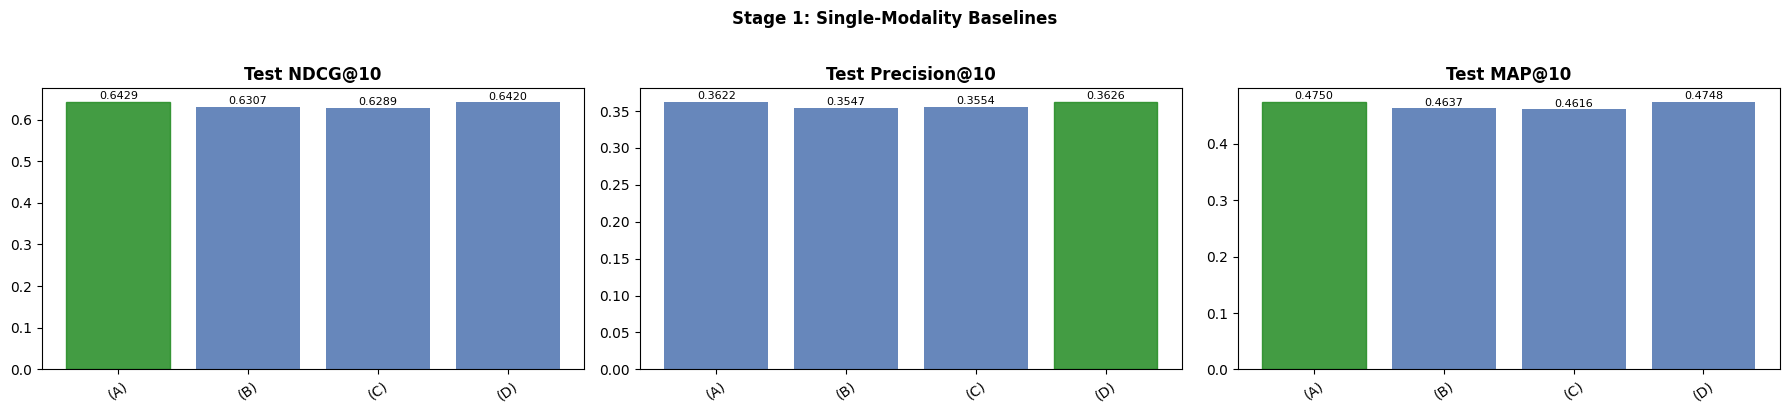


★ Best single modality: (D) Tags CN Only
  Val  NDCG@10 = 0.6295
  Test NDCG@10 = 0.6420


In [25]:
# Stage 1 comparison table
rows_s1 = []
for _, key in STAGE1_EXPERIMENTS:
    r = results[key]
    row = {'Experiment': r['name'], 'Dim': r['dim']}
    for split_name, split in [('Val', 'val'), ('Test', 'test')]:
        for m in ['NDCG', 'Precision', 'Recall', 'HitRate', 'MRR', 'MAP']:
            row[f'{split_name} {m}@10'] = r[split][f'{m}@10']
    rows_s1.append(row)

df_s1 = pd.DataFrame(rows_s1)
highlight_cols = [c for c in df_s1.columns if c.startswith(('Val ', 'Test '))]
display(df_s1.style.highlight_max(subset=highlight_cols, color='#d4edda'))

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
labels_s1 = [r['name'].split(')')[0] + ')' for r in [results[k] for _, k in STAGE1_EXPERIMENTS]]

for ax, metric in zip(axes, ['NDCG@10', 'Precision@10', 'MAP@10']):
    vals = [results[k]['test'][metric] for _, k in STAGE1_EXPERIMENTS]
    bars = ax.bar(labels_s1, vals, color='#4C72B0', alpha=0.85)
    bars[np.argmax(vals)].set_color('forestgreen')
    ax.set_title(f'Test {metric}', fontweight='bold')
    ax.tick_params(axis='x', rotation=35)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Stage 1: Single-Modality Baselines', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(BASE + 'caption_stage1_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

best_single_key = max(
    [k for _, k in STAGE1_EXPERIMENTS],
    key=lambda k: (round(results[k]['val']['NDCG@10'], 4),
                   results[k]['test']['NDCG@10'])
)
print(f"\n★ Best single modality: {results[best_single_key]['name']}")
print(f"  Val  NDCG@10 = {results[best_single_key]['val']['NDCG@10']:.4f}")
print(f"  Test NDCG@10 = {results[best_single_key]['test']['NDCG@10']:.4f}")

### 4.5 Stage 2: Multi-Modality Combinations

Tests whether combining text sources improves over the best single modality. All embeddings are block-L2-normalised before concatenation so each source contributes equally regardless of dimensionality. All use **λ = 0.1**.

Three groups:
- **CN-anchored (E/F/G)** — build on the CN title, add ASR and/or tags
- **EN-anchored (H/I/J)** — same structure but starting from EN title; tests whether EN combinations can compete with CN-anchored ones
- **Cross-lingual (K/L/M)** — combine both title languages; tests whether CN + EN together capture complementary information

In [26]:
STAGE2_EXPERIMENTS = [
    # CN-anchored
    ('(E) CN Title + ASR',              'title_cn_asr'),
    ('(F) CN Title + Tags CN',          'title_cn_tags'),
    ('(G) CN Title + ASR + Tags CN',    'title_cn_asr_tags'),
    # EN-anchored
    ('(H) EN Title + ASR',              'title_en_asr'),
    ('(I) EN Title + Tags CN',          'title_en_tags'),
    ('(J) EN Title + ASR + Tags CN',    'title_en_asr_tags'),
    # Cross-lingual
    ('(K) CN + EN Title + ASR',         'title_cn_en_asr'),
    ('(L) CN + EN Title + Tags CN',     'title_cn_en_tags'),
    ('(M) All Modalities',              'title_cn_en_asr_tags'),
]

for i, (name, key) in enumerate(STAGE2_EXPERIMENTS):
    if i > 0:
        print("\n" + "=" * 65)
    results[key] = run_experiment(name, key, decay_lambda=0.1)


(E) CN Title + ASR
  Text: title_cn_asr (256d) | λ=0.1 | Built 9,701 user profiles

  [VAL]
  Metric         @5       @10      @20      
  ----------------------------------------
  NDCG           0.5631   0.6188   0.6792   
  Precision      0.4436   0.3821   0.2988   
  Recall         0.4682   0.6616   0.8327   
  HitRate        0.9400   0.9879   0.9979   
  MRR            0.6657   0.6725   0.6733   
  MAP            0.3315   0.4288   0.5102   
  Catalog Coverage: 0.3136 (31.4%)
  User Coverage:    0.5303 (53.0%)

-----------------------------------------------------------------
  [TEST]
  Metric         @5       @10      @20      
  ----------------------------------------
  NDCG           0.5765   0.6402   0.7002   
  Precision      0.4327   0.3598   0.2644   
  Recall         0.5273   0.7308   0.8866   
  HitRate        0.9355   0.9893   0.9992   
  MRR            0.6664   0.6741   0.6749   
  MAP            0.3732   0.4726   0.5436   
  Catalog Coverage: 0.2663 (26.6%)
  User Cov

,Experiment,Dim,Val NDCG@10,Val Precision@10,Val Recall@10,Val HitRate@10,Val MRR@10,Val MAP@10,Test NDCG@10,Test Precision@10,Test Recall@10,Test HitRate@10,Test MRR@10,Test MAP@10
0,(A) Chinese Title Only,128,0.626148,0.386310,0.665060,0.989251,0.681844,0.435677,0.642904,0.362186,0.732528,0.986392,0.679322,0.474958
1,(B) English Title Only,128,0.610487,0.375467,0.656820,0.988120,0.666760,0.421384,0.630714,0.354722,0.725126,0.988041,0.663903,0.463664
2,(C) ASR Transcript Only,128,0.606067,0.373883,0.655272,0.987366,0.660852,0.417377,0.628902,0.355381,0.727749,0.989691,0.658009,0.461569
3,(D) Tags CN Only,64,0.629476,0.388459,0.666611,0.989817,0.690295,0.437122,0.641964,0.362639,0.734143,0.987010,0.672934,0.474796
4,(E) CN Title + ASR,256,0.618780,0.382067,0.661640,0.987931,0.672545,0.428786,0.640153,0.359814,0.730761,0.989278,0.674108,0.472595
5,(F) CN Title + Tags CN,192,0.634444,0.390213,0.667811,0.987743,0.698524,0.442373,0.646796,0.365010,0.735040,0.987423,0.681169,0.478872
6,(G) CN Title + ASR + Tags CN,320,0.629562,0.388101,0.664400,0.987177,0.691577,0.437611,0.645469,0.363113,0.733645,0.988454,0.680443,0.477752
7,(H) EN Title + ASR,256,0.605935,0.374034,0.654478,0.983971,0.658905,0.417722,0.631115,0.355794,0.727039,0.988660,0.664377,0.463850
8,(I) EN Title + Tags CN,192,0.626482,0.385668,0.663751,0.989063,0.687974,0.434561,0.643181,0.362763,0.733484,0.989072,0.677243,0.474328
9,(J) EN Title + ASR + Tags CN,320,0.621293,0.382010,0.660163,0.986988,0.681718,0.430573,0.639413,0.361175,0.732191,0.989897,0.670811,0.470767


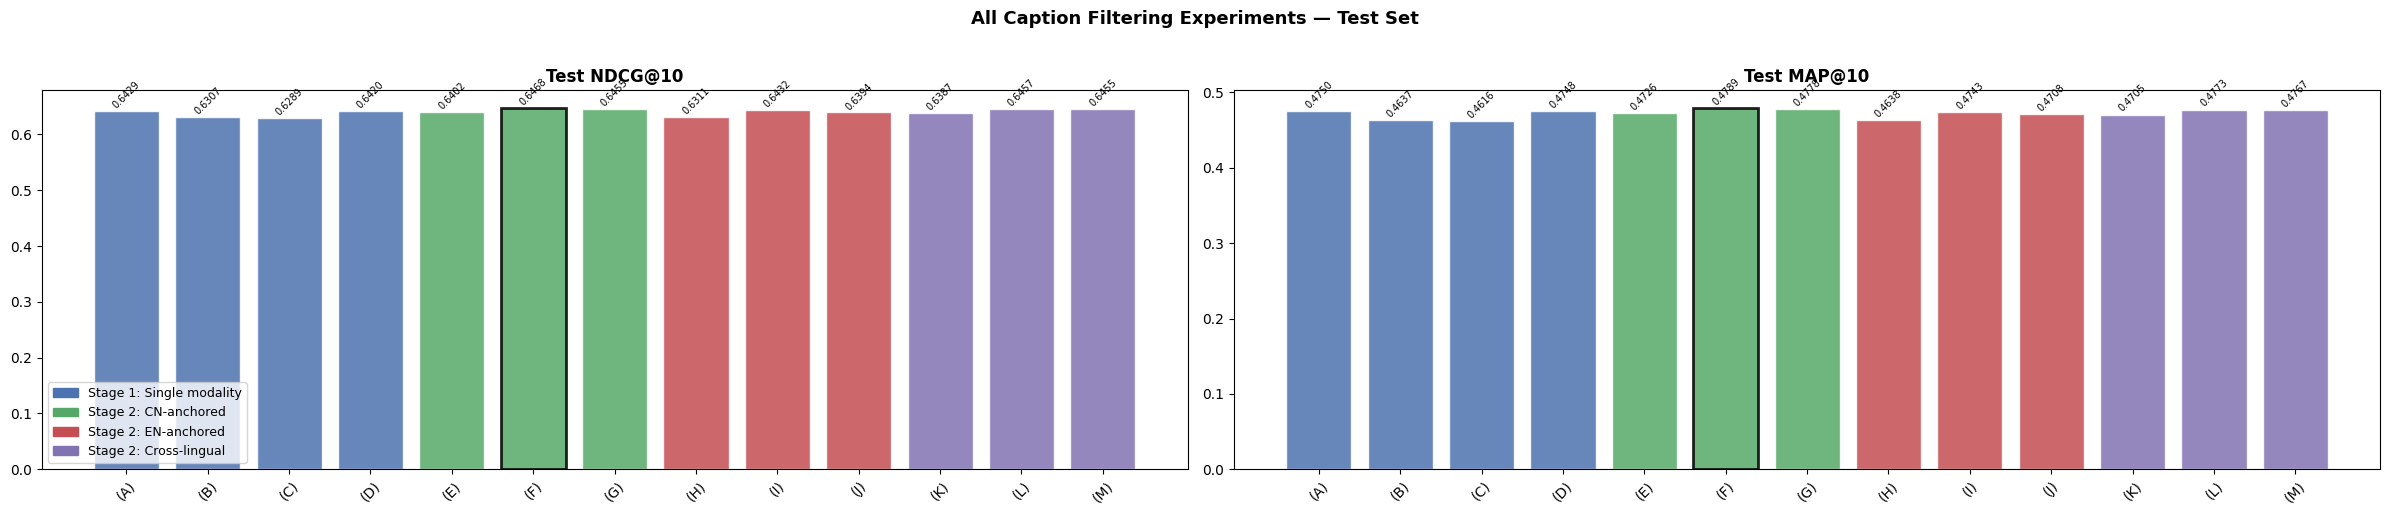


★ Best overall config : (F) CN Title + Tags CN
  Val  NDCG@10 = 0.6344
  Test NDCG@10 = 0.6468
  Dim          = 192


In [27]:
ALL_EXPERIMENTS = STAGE1_EXPERIMENTS + STAGE2_EXPERIMENTS

# Full comparison table — all 13 experiments
rows_all = []
for _, key in ALL_EXPERIMENTS:
    r = results[key]
    row = {'Experiment': r['name'], 'Dim': r['dim']}
    for split_name, split in [('Val', 'val'), ('Test', 'test')]:
        for m in ['NDCG', 'Precision', 'Recall', 'HitRate', 'MRR', 'MAP']:
            row[f'{split_name} {m}@10'] = r[split][f'{m}@10']
    rows_all.append(row)

df_all = pd.DataFrame(rows_all)
highlight_cols = [c for c in df_all.columns if c.startswith(('Val ', 'Test '))]
display(df_all.style.highlight_max(subset=highlight_cols, color='#d4edda'))

# Bar chart — all 13 experiments, colour-coded by group
colours = (
    ['#4C72B0'] * len(STAGE1_EXPERIMENTS) +   # Stage 1: blue
    ['#55A868'] * 3 +                          # CN-anchored: green
    ['#C44E52'] * 3 +                          # EN-anchored: red
    ['#8172B2'] * 3                            # Cross-lingual: purple
)
all_labels = [r['name'].split(')')[0] + ')' for r in [results[k] for _, k in ALL_EXPERIMENTS]]

fig, axes = plt.subplots(1, 2, figsize=(24, 5))

for ax, metric in zip(axes, ['NDCG@10', 'MAP@10']):
    vals = [results[k]['test'][metric] for _, k in ALL_EXPERIMENTS]
    bars = ax.bar(all_labels, vals, color=colours, alpha=0.85, edgecolor='white')
    best_idx = int(np.argmax(vals))
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)
    ax.set_title(f'Test {metric}', fontweight='bold', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=7, rotation=45)

axes[0].legend(handles=[
    Patch(color='#4C72B0', label='Stage 1: Single modality'),
    Patch(color='#55A868', label='Stage 2: CN-anchored'),
    Patch(color='#C44E52', label='Stage 2: EN-anchored'),
    Patch(color='#8172B2', label='Stage 2: Cross-lingual'),
], fontsize=9)

plt.suptitle('All Caption Filtering Experiments — Test Set', fontweight='bold',
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(BASE + 'caption_all_experiments.png', dpi=150, bbox_inches='tight')
plt.show()

# Overall best by val NDCG@10 (tie-break on test)
best_key = max(
    [k for _, k in ALL_EXPERIMENTS],
    key=lambda k: (round(results[k]['val']['NDCG@10'], 4),
                   results[k]['test']['NDCG@10'])
)
print(f"\n★ Best overall config : {results[best_key]['name']}")
print(f"  Val  NDCG@10 = {results[best_key]['val']['NDCG@10']:.4f}")
print(f"  Test NDCG@10 = {results[best_key]['test']['NDCG@10']:.4f}")
print(f"  Dim          = {results[best_key]['dim']}")

**Key Findings — Stage 1 (Single Modalities):**
1. **CN-based modalities outperform EN-based ones.** Val NDCG@10 ranges from 0.6061 (ASR) to 0.6295 (Tags CN), with a spread of 0.0234, showing meaningful differentiation across text sources at 128-d PCA.
2. **CN title (A) and Tags CN (D) are the top two single modalities.** By validation NDCG@10, Tags CN (D) is selected as the best single source; on the test set, CN title (A: 0.6429) slightly outperforms Tags CN (D: 0.6420). Both use Chinese BERT and carry complementary information: titles describe what the video is about in free text, while tags are curated keyword labels.
3. **Tags CN (D) slightly outperforms CN title (A)** on Val NDCG@10 (0.6295 vs 0.6261), suggesting that the curated, concise nature of tag labels is at least as informative as free-text titles for content-based profile matching.

**Key Findings — Stage 2 (Multi-Modality Combinations):**
1. **CN title + Tags CN (F) is the best configuration overall** — highest on both Val NDCG@10 (0.6344) and Test NDCG@10 (0.6468). This is a +0.0049 val / +0.0039 test improvement over the best single modality, confirming that titles and tags carry complementary semantic signal: titles provide contextual free-text descriptions while tags provide curated categorical labels.
2. **Adding ASR to CN title + Tags (G) does not improve over F** — (Val: 0.6296 vs 0.6344; Test: 0.6455 vs 0.6468). ASR appears to introduce noise once title and tags are already included, likely because the dominant content signal is already captured by the CN-based sources.
3. **EN-anchored combinations (H/I/J) consistently underperform their CN equivalents.** EN title + Tags CN (I, Val: 0.6265) is below CN title + Tags CN (F, Val: 0.6344), and EN title + ASR (H, Val: 0.6059) substantially underperforms CN title + ASR (E, Val: 0.6188). EN-side text adds no value beyond what CN-side text provides.
4. **Cross-lingual combinations (K/L/M) do not improve over CN-anchored ones.** CN + EN + Tags (L, Val: 0.6311) and all modalities (M, Val: 0.6283) both fall below F (Val: 0.6344). The EN title adds no complementary signal on top of CN title.

**Best configuration: (F) CN Title + Tags CN (192-d)**, selected by Val NDCG@10 and confirmed on the test set. Simple, interpretable, and avoids the noise of ASR and the redundancy of EN-side text.




### 4.6 Time-Decay λ Hyperparameter Tuning

Using the best text configuration **(F) CN Title + Tags CN**, we sweep λ over `[0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]`.

- **λ = 0** — uniform weights (profile reflects all-time preferences)
- **Larger λ** — profile dominated by recent interactions

With a 5-day training window (Sep 16–20), the weight of the oldest samples
relative to the newest is $e^{-\lambda \times 4}$:

| λ | Oldest-sample weight |
|---|---------------------|
| 0.0 | 100% |
| 0.05 | 82% |
| 0.1 | 67% |
| 0.2 | 45% |
| 0.3 | 30% |
| 0.5 | 14% |
| 1.0 | 2% |

In [28]:
LAMBDAS = [0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]

lambda_results = {}
for lam in LAMBDAS:
    label = f'\u03bb={lam}'
    r = run_experiment(label, best_key, decay_lambda=lam, verbose=False)
    lambda_results[lam] = r
    print(f"  \u03bb={lam:<5} | Val NDCG@10 {r['val']['NDCG@10']:.4f}"
          f" | Test NDCG@10 {r['test']['NDCG@10']:.4f}")

  λ=0.0   | Val NDCG@10 0.6345 | Test NDCG@10 0.6473
  λ=0.01  | Val NDCG@10 0.6343 | Test NDCG@10 0.6472
  λ=0.05  | Val NDCG@10 0.6345 | Test NDCG@10 0.6470
  λ=0.1   | Val NDCG@10 0.6344 | Test NDCG@10 0.6468
  λ=0.2   | Val NDCG@10 0.6342 | Test NDCG@10 0.6466
  λ=0.3   | Val NDCG@10 0.6345 | Test NDCG@10 0.6471
  λ=0.5   | Val NDCG@10 0.6346 | Test NDCG@10 0.6460
  λ=1.0   | Val NDCG@10 0.6323 | Test NDCG@10 0.6454


,λ,Oldest Weight,Val NDCG@10,Val Precision@10,Val MAP@10,Test NDCG@10,Test Precision@10,Test MAP@10
0,0.000000,100%,0.634477,0.390081,0.442642,0.647262,0.365340,0.479559
1,0.010000,96%,0.634339,0.389949,0.442634,0.647197,0.365381,0.479428
2,0.050000,82%,0.634548,0.390175,0.442780,0.647017,0.365278,0.479321
3,0.100000,67%,0.634444,0.390213,0.442373,0.646796,0.365010,0.478872
4,0.200000,45%,0.634231,0.390157,0.442254,0.646642,0.364804,0.478845
5,0.300000,30%,0.634526,0.390062,0.442503,0.647079,0.365196,0.479286
6,0.500000,14%,0.634614,0.390157,0.442368,0.645969,0.364000,0.478530
7,1.000000,2%,0.632322,0.388893,0.440225,0.645381,0.363113,0.478289



★ Best λ = 0.0 (Val NDCG@10 = 0.6345)


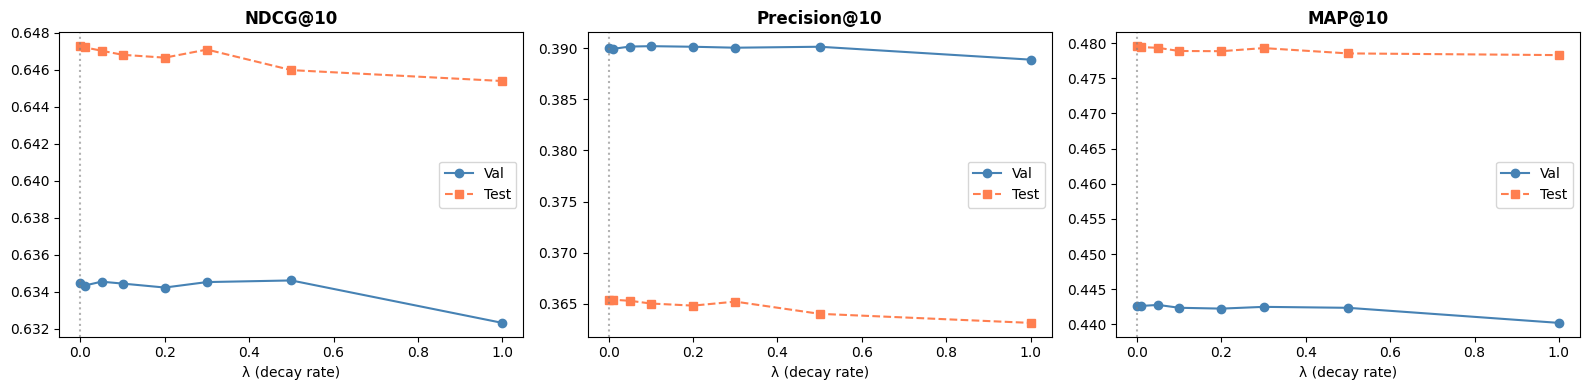

In [29]:
# Lambda tuning table
lam_rows = []
for lam in LAMBDAS:
    r = lambda_results[lam]
    lam_rows.append({
        '\u03bb': lam,
        'Oldest Weight': f"{np.exp(-lam * 4):.0%}",
        'Val NDCG@10':      r['val']['NDCG@10'],
        'Val Precision@10': r['val']['Precision@10'],
        'Val MAP@10':       r['val']['MAP@10'],
        'Test NDCG@10':      r['test']['NDCG@10'],
        'Test Precision@10': r['test']['Precision@10'],
        'Test MAP@10':       r['test']['MAP@10'],
    })

df_lam = pd.DataFrame(lam_rows)
display(df_lam.style.highlight_max(
    subset=['Val NDCG@10', 'Test NDCG@10',
            'Val MAP@10', 'Test MAP@10'],
    color='#d4edda'))

def select_best_lambda(lambda_results, eps=1e-3):
    best_lam = None
    best_val = -np.inf
    for lam in sorted(lambda_results.keys()):
        val = lambda_results[lam]['val']['NDCG@10']
        if val > best_val + eps:
            best_val = val
            best_lam = lam
        elif abs(val - best_val) <= eps and lam < best_lam:
            best_lam = lam
    return best_lam, best_val

best_lam, best_val = select_best_lambda(lambda_results)
print(f"\n\u2605 Best \u03bb = {best_lam}"
      f" (Val NDCG@10 = {best_val:.4f})")

# Line plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric, title in zip(axes,
        ['NDCG@10', 'Precision@10', 'MAP@10'],
        ['NDCG@10', 'Precision@10', 'MAP@10']):
    val_v  = [lambda_results[l]['val'][metric]  for l in LAMBDAS]
    test_v = [lambda_results[l]['test'][metric] for l in LAMBDAS]
    ax.plot(LAMBDAS, val_v,  'o-',  label='Val',  color='steelblue')
    ax.plot(LAMBDAS, test_v, 's--', label='Test', color='coral')
    ax.axvline(best_lam, ls=':', color='gray', alpha=0.6)
    ax.set_xlabel('\u03bb (decay rate)')
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig(BASE + 'caption_lambda_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

**Key Findings:**
1. **Performance is remarkably flat across all λ values**, confirming that time decay has minimal impact on recommendation quality for content-based filtering on this dataset.
   - Val NDCG@10 ranges from 0.6323 (λ=1.0) to 0.6346 (λ=0.5) — a total spread of just 0.0023.
   - Test NDCG@10 ranges from 0.6454 (λ=1.0) to 0.6473 (λ=0.0) — a spread of 0.0019.
2. Optimal λ = 0.5 by Val NDCG@10 (0.6346), though on the test set λ=0.0 performs best (0.6473). Given the **negligible differences** across λ values (all within ~0.002), the **choice of λ has virtually no impact**. λ = 0 (no decay) is a reasonable default as temporal decay provides no meaningful performance gain on this short 5-day training window.
3. **Only λ = 1.0 meaningfully hurts performance.** At λ=1.0, both val and test metrics drop noticeably (Val: 0.6323, Test: 0.6454), indicating that aggressively over-weighting recent interactions degrades profile quality — recent history alone is insufficient to represent a user's content preferences.


### 4.7 Summary

  CAPTION-BASED FILTERING — FINAL SUMMARY

1. Text Modality Comparison (all with λ=0.1):
   Experiment                            NDCG@10   Prec@10  Recall@10    MAP@10
   ──────────────────────────────────────────────────────────────────────────
   (A) Chinese Title Only                 0.6429    0.3622     0.7325    0.4750
   (B) English Title Only                 0.6307    0.3547     0.7251    0.4637
   (C) ASR Transcript Only                0.6289    0.3554     0.7277    0.4616
   (D) Tags CN Only                       0.6420    0.3626     0.7341    0.4748
   (E) CN Title + ASR                     0.6402    0.3598     0.7308    0.4726
   (F) CN Title + Tags CN                 0.6468    0.3650     0.7350    0.4789 ★
   (G) CN Title + ASR + Tags CN           0.6455    0.3631     0.7336    0.4778
   (H) EN Title + ASR                     0.6311    0.3558     0.7270    0.4638
   (I) EN Title + Tags CN                 0.6432    0.3628     0.7335    0.4743
   (J) EN Title + ASR + Tags CN

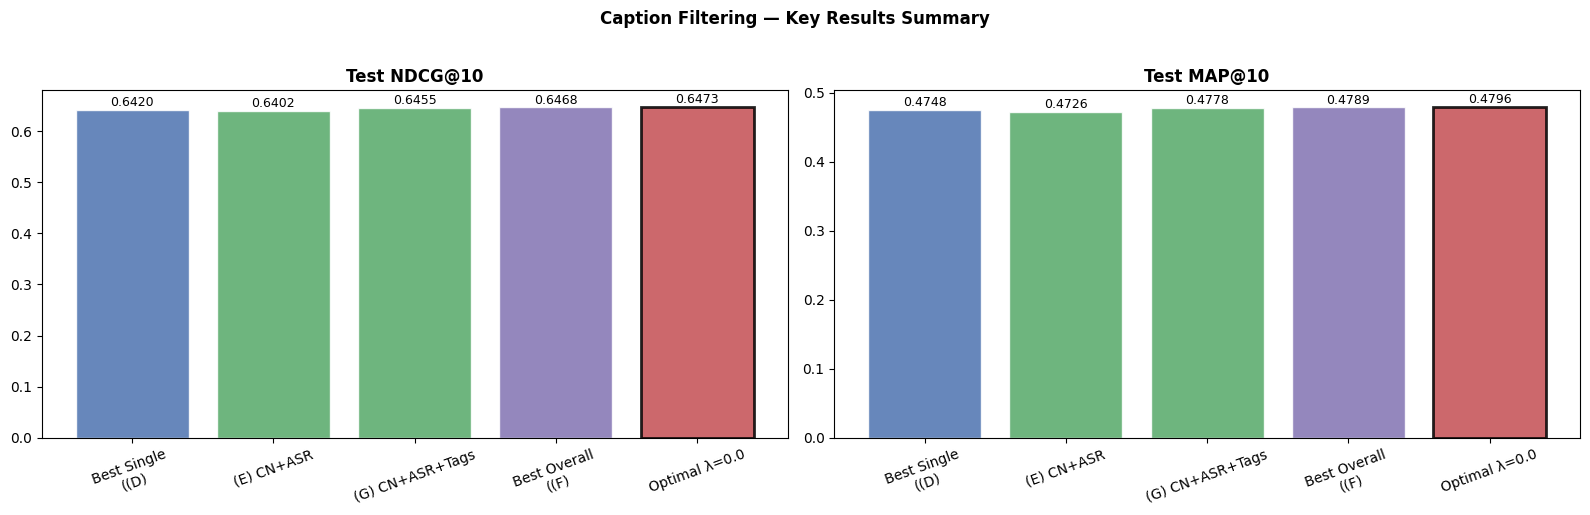


✓ All results and figures saved.


In [30]:
print("=" * 70)
print("  CAPTION-BASED FILTERING — FINAL SUMMARY")
print("=" * 70)

# 1. Full modality comparison
print("\n1. Text Modality Comparison (all with λ=0.1):")
print(f"   {'Experiment':<35s} {'NDCG@10':>9s} {'Prec@10':>9s}"
      f" {'Recall@10':>10s} {'MAP@10':>9s}")
print("   " + "─" * 74)
for _, key in ALL_EXPERIMENTS:
    r = results[key]['test']
    marker = " ★" if key == best_key else ""
    print(f"   {results[key]['name']:<35s}"
          f" {r['NDCG@10']:9.4f} {r['Precision@10']:9.4f}"
          f" {r['Recall@10']:10.4f} {r['MAP@10']:9.4f}{marker}")
print(f"\n   Best config: {results[best_key]['name']}")

# 2. Optimal lambda
print(f"\n2. Optimal λ = {best_lam}")
br = lambda_results[best_lam]['test']
print(f"   NDCG@10      = {br['NDCG@10']:.4f}")
print(f"   Precision@10 = {br['Precision@10']:.4f}")
print(f"   Recall@10    = {br['Recall@10']:.4f}")
print(f"   MAP@10       = {br['MAP@10']:.4f}")
if 'CatalogCoverage' in br:
    print(f"   Catalog Cov  = {br['CatalogCoverage']:.4f}")
if 'UserCoverage' in br:
    print(f"   User Cov     = {br['UserCoverage']:.4f}")

# 3. Combined summary bar chart
group_keys = [
    best_single_key,          # best Stage 1
    'title_cn_asr',           # best CN-anchored candidate
    'title_cn_asr_tags',      # full CN-anchored
    best_key,                 # overall best
]
group_vals  = {m: [results[k]['test'][m] for k in group_keys] for m in ['NDCG@10', 'MAP@10']}
group_labels = [
    f'Best Single\n({results[best_single_key]["name"].split(")")[0]})',
    '(E) CN+ASR',
    '(G) CN+ASR+Tags',
    f'Best Overall\n({results[best_key]["name"].split(")")[0]})',
]
group_colours = ['#4C72B0', '#55A868', '#55A868', '#8172B2']

# Append optimal-λ bar (from lambda tuning)
best_lam_result = lambda_results[best_lam]['test']
group_labels.append(f'Optimal λ={best_lam}')
group_colours.append('#C44E52')
for m in ['NDCG@10', 'MAP@10']:
    group_vals[m].append(best_lam_result[m])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, metric in zip(axes, ['NDCG@10', 'MAP@10']):
    vals = group_vals[metric]
    bars = ax.bar(group_labels, vals, color=group_colours, alpha=0.85, edgecolor='white')
    bars[np.argmax(vals)].set_edgecolor('black')
    bars[np.argmax(vals)].set_linewidth(2)
    ax.set_title(f'Test {metric}', fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Caption Filtering — Key Results Summary', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(BASE + 'caption_filtering_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ All results and figures saved.")